In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/Users/16692/Downloads/archive (3)/linear_equations_2_variables.csv", encoding='latin-1')

In [3]:
df.head()

,a1,b1,c1,a2,b2,c2,x,y
0,16,37,-75,60,-40,99,-0.231818,2.127273
1,-79,13,31,-27,-3,-19,-0.261905,-3.976190
2,-85,-66,94,54,83,-100,0.344314,0.980808
3,66,-40,-82,-53,-26,70,1.285714,0.071429
4,53,5,-68,-96,-100,-59,1.471992,-2.003112


In [4]:
from sklearn.model_selection import train_test_split 

In [5]:
X=df[['a1','b1','c1','a2','b2','c2']]
y=df[['x','y']]

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2)
X_val , X_test , y_val , y_test = train_test_split(X , y, test_size=0.5 , random_state=42)

 Model 1 : Linear Regression 

In [7]:
from sklearn.linear_model import LinearRegression 
reg = LinearRegression()
reg.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
import numpy as np 
def evaluate(model , X , y):
    y_predict=model.predict(X)
    mae=mean_absolute_error(y , y_predict)
    rmse= np.sqrt(mean_squared_error(y,y_predict))
    r2= r2_score(y,y_predict)
    return mae , rmse ,r2

In [9]:
mae_val , rmse_val , r2_val = evaluate(reg,X_val , y_val)
mae_test , rmse_test ,r2_test= evaluate (reg , X_test , y_test)
print(f"Validation Set -> MAE : {mae_val} , RMSE : {rmse_val} , R2 : {r2_val}")
print(f"Test Set -> MAE : {mae_test} , RMSE : {rmse_test} , R2 : {r2_test}")

Validation Set -> MAE : 5.36085599575511 , RMSE : 73.92168060860837 , R2 : 0.00013651207517512143
Test Set -> MAE : 4.978093404275626 , RMSE : 63.960077817906416 , R2 : -0.00014222715471834402


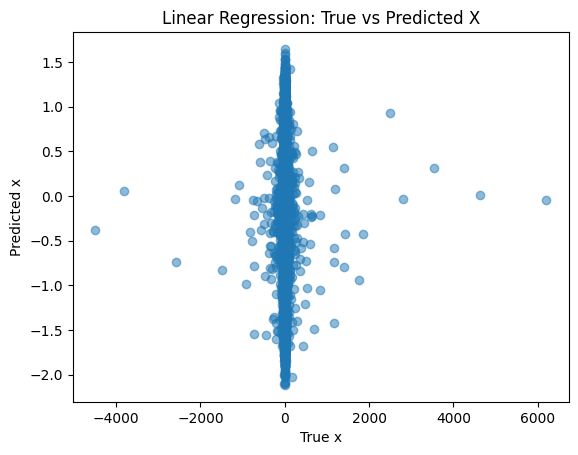

In [10]:
import matplotlib.pyplot as plt
y_pred= reg.predict(X_test)
plt.scatter(y_test["x"], y_pred[:, 0], alpha=0.5)
plt.xlabel("True x")
plt.ylabel("Predicted x")
plt.title("Linear Regression: True vs Predicted X")
plt.show()


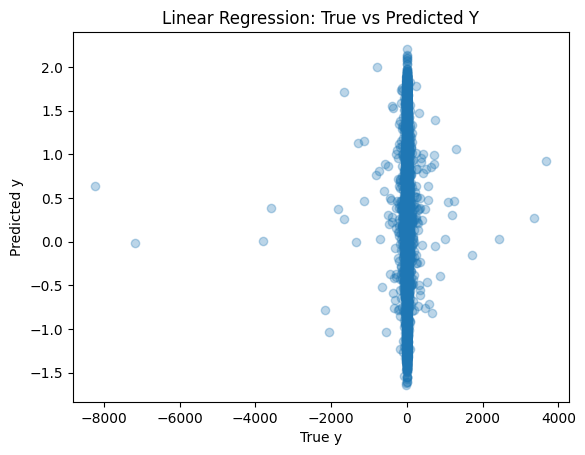

In [11]:
import matplotlib.pyplot as plt
plt.scatter(y_test["y"], y_pred[:, 1], alpha=0.3)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Linear Regression: True vs Predicted Y")
plt.show()



Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)


In [13]:
mae_rf, rmse_rf, r2_rf = evaluate(rf, X_test, y_test)

print(f"Random Forest Test Set -> MAE: {mae_rf}, RMSE: {rmse_rf}, R2: {r2_rf}")




Random Forest Test Set -> MAE: 4.648164862796824, RMSE: 54.900907929058405, R2: 0.25939239697982036


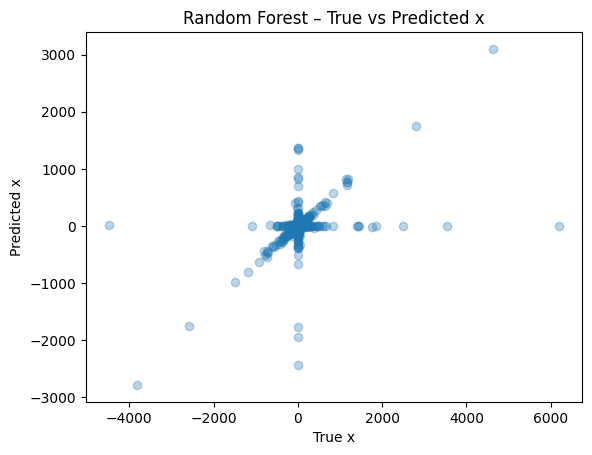

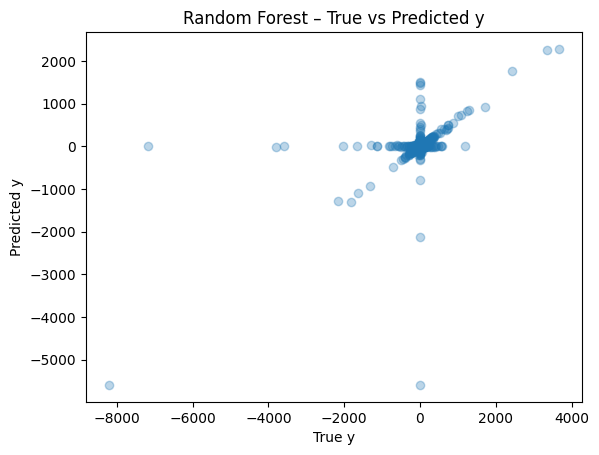

In [14]:
y_pred = rf.predict(X_test)

plt.scatter(y_test["x"], y_pred[:,0], alpha=0.3)
plt.xlabel("True x")
plt.ylabel("Predicted x")
plt.title("Random Forest – True vs Predicted x")
plt.show()

plt.scatter(y_test["y"], y_pred[:,1], alpha=0.3)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Random Forest – True vs Predicted y")
plt.show()


Model 3: KNN

In [15]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


In [16]:
mae_knn, rmse_knn, r2_knn = evaluate(knn, X_test, y_test)

print(f"KNN Test Set -> MAE: {mae_knn}, RMSE: {rmse_knn}, R2: {r2_knn}")

KNN Test Set -> MAE: 5.814870091688759, RMSE: 63.297304107249545, R2: 0.014056826153284463


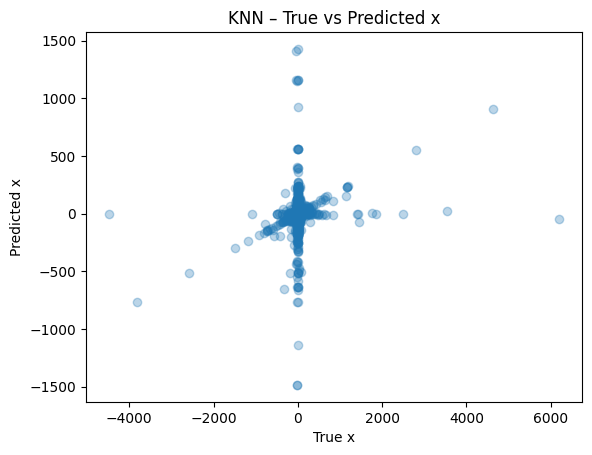

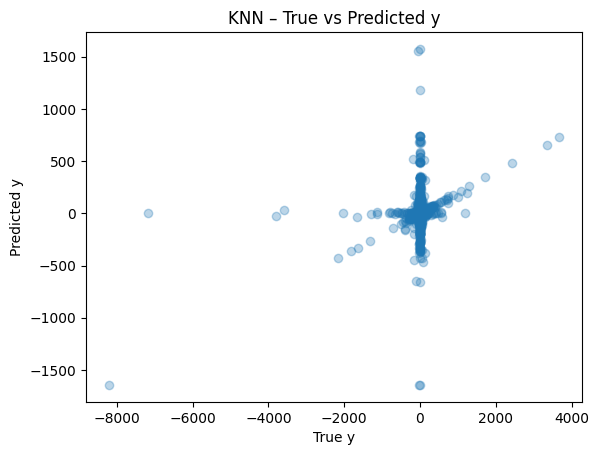

In [17]:
y_pred = knn.predict(X_test)

plt.scatter(y_test["x"], y_pred[:,0], alpha=0.3)
plt.xlabel("True x")
plt.ylabel("Predicted x")
plt.title("KNN – True vs Predicted x")
plt.show()
plt.scatter(y_test["y"], y_pred[:,1], alpha=0.3)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("KNN – True vs Predicted y")
plt.show()


Model 4: Artificial Neural Network 

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# Convert pandas DataFrames to numpy arrays
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
X_val_np = np.array(X_val)
y_val_np = np.array(y_val)



In [31]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_np)
X_val_s   = scaler.transform(X_val_np)


In [32]:
def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_s.shape[1],)),
        Dense(64, activation='relu'),
        Dense(2)  # predict x and y
    ])
    return model


In [50]:
model_adam = build_model()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_adam = model_adam.fit(
    X_train_s, y_train_np,
    validation_data=(X_val_s, y_val_np),
    epochs=150,
    batch_size=32,
    verbose=0
)


In [51]:
model_sgd = build_model()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.0),
    loss='mse',
    metrics=['mae']
)

history_sgd = model_sgd.fit(
    X_train_s, y_train_np,
    validation_data=(X_val_s, y_val_np),
    epochs=150,
    batch_size=32,
    verbose=0
)


In [52]:
model_momentum = build_model()
model_momentum.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9),
    loss='mse',
    metrics=['mae']
)

history_momentum = model_momentum.fit(
    X_train_s, y_train_np,
    validation_data=(X_val_s, y_val_np),
    epochs=150,
    batch_size=32,
    verbose=0
)


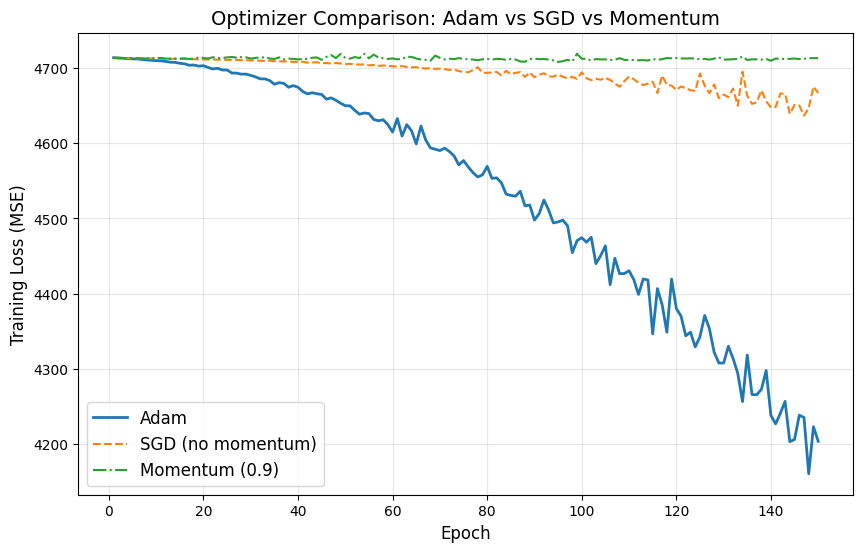

In [54]:
plt.figure(figsize=(10,6))
epochs = range(1, 151)

plt.plot(epochs, history_adam.history['loss'], label='Adam', linewidth=2)
plt.plot(epochs, history_sgd.history['loss'], label='SGD (no momentum)', linestyle='--')
plt.plot(epochs, history_momentum.history['loss'], label='Momentum (0.9)', linestyle='-.')

plt.title("Optimizer Comparison: Adam vs SGD vs Momentum", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Training Loss (MSE)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()


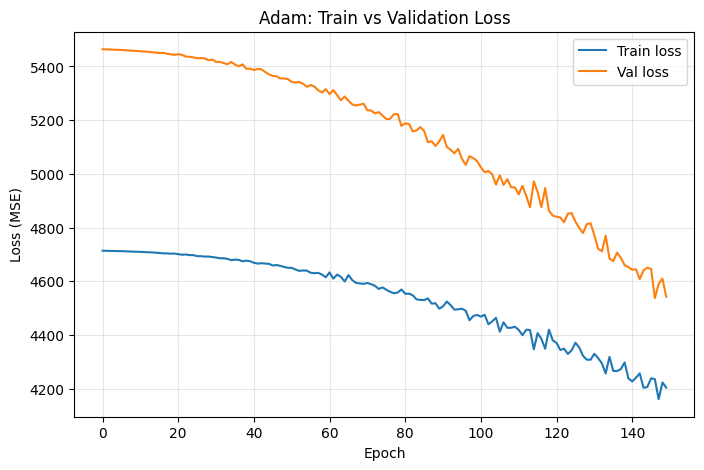

In [55]:
plt.figure(figsize=(8,5))
plt.plot(history_adam.history['loss'], label='Train loss')
plt.plot(history_adam.history['val_loss'], label='Val loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Adam: Train vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Model 5: Support Vector Machine

In [45]:
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
import numpy as np

# Linear SVR is sensitive to feature scale → scale X
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train)
X_val_svm   = scaler_svm.transform(X_val)
X_test_svm  = scaler_svm.transform(X_test)

# Train model
linsvr = LinearSVR(epsilon=0.1, C=1.0, random_state=42)
linsvr.fit(X_train_svm, y_train['x'])   # x model
linsvr_y = LinearSVR(epsilon=0.1, C=1.0, random_state=42)
linsvr_y.fit(X_train_svm, y_train['y'])  # y model


,epsilon,0.1
,tol,0.0001
,C,1.0
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,42
,max_iter,1000


In [46]:
y_pred_x = linsvr.predict(X_test_svm)
y_pred_y = linsvr_y.predict(X_test_svm)

y_pred_linsvr = np.column_stack([y_pred_x, y_pred_y])

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_linsvr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linsvr))
r2 = r2_score(y_test, y_pred_linsvr)

print("LinearSVR Results:")
print("  MAE :", mae)
print("  RMSE:", rmse)
print("  R²  :", r2)


LinearSVR Results:
  MAE : 4.874742111676085
  RMSE: 63.956482729519955
  R²  : -3.24762423433711e-05


In [47]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# scale first
scaler_poly = StandardScaler()
X_train_poly = scaler_poly.fit_transform(X_train)
X_val_poly   = scaler_poly.transform(X_val)
X_test_poly  = scaler_poly.transform(X_test)

svr_poly_x = SVR(kernel='poly', degree=3, C=1.0, epsilon=0.1)
svr_poly_x.fit(X_train_poly, y_train['x'])

svr_poly_y = SVR(kernel='poly', degree=3, C=1.0, epsilon=0.1)
svr_poly_y.fit(X_train_poly, y_train['y'])


,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [48]:
y_pred_x = svr_poly_x.predict(X_test_poly)
y_pred_y = svr_poly_y.predict(X_test_poly)

y_pred_poly = np.column_stack([y_pred_x, y_pred_y])

mae = mean_absolute_error(y_test, y_pred_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2 = r2_score(y_test, y_pred_poly)

print("SVR (Polynomial Kernel) Results:")
print("  MAE :", mae)
print("  RMSE:", rmse)
print("  R2  :", r2)


SVR (Polynomial Kernel) Results:
  MAE : 4.874107137532391
  RMSE: 63.95703003444601
  R2  : -4.823107471318977e-05


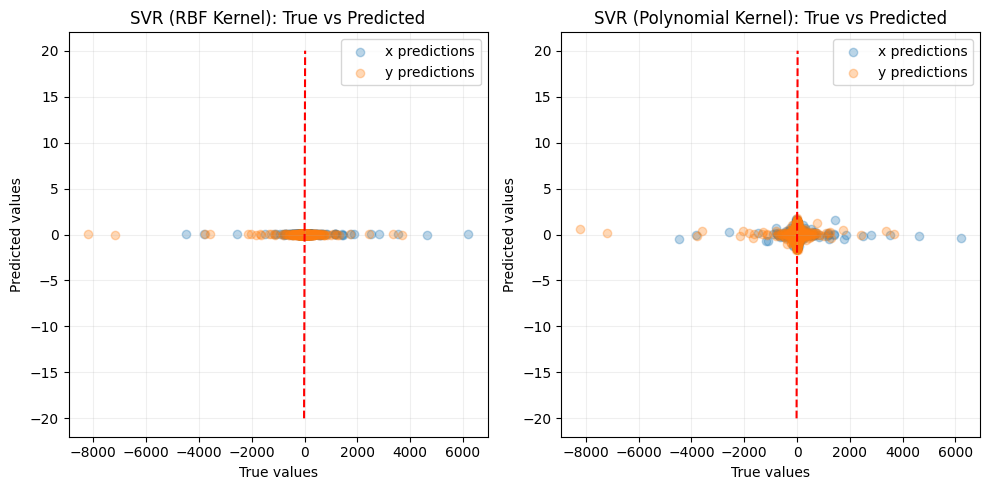

In [49]:
plt.figure(figsize=(10,5))

# --- RBF ---
plt.subplot(1,2,1)
plt.scatter(y_test['x'], y_pred_linsvr[:,0], alpha=0.3, label='x predictions')
plt.scatter(y_test['y'], y_pred_linsvr[:,1], alpha=0.3, label='y predictions')
plt.plot([-20,20], [-20,20], 'r--')  # diagonal reference line
plt.title("SVR (RBF Kernel): True vs Predicted")
plt.xlabel("True values"); plt.ylabel("Predicted values")
plt.legend()
plt.grid(True, alpha=0.2)

# --- Polynomial ---
plt.subplot(1,2,2)
plt.scatter(y_test['x'], y_pred_poly[:,0], alpha=0.3, label='x predictions')
plt.scatter(y_test['y'], y_pred_poly[:,1], alpha=0.3, label='y predictions')
plt.plot([-20,20], [-20,20], 'r--')
plt.title("SVR (Polynomial Kernel): True vs Predicted")
plt.xlabel("True values"); plt.ylabel("Predicted values")
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
